In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [10]:
import pandas as pd

df = pd.read_csv(
    r"E:\my new for the me last for the change the my life for the life only goal\project\Digital Payments Fraud Intelligence\Database\clean\clean.csv"
)

df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [11]:
df.head()

,transaction_id,timestamp,transaction_type,merchant_category,amount_inr,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [13]:
# check if there are any missing values in the dataset

df.isnull().sum()

transaction_id        0
timestamp             0
transaction_type      0
merchant_category     0
amount_inr            0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [14]:
total_transactions = len(df)

total_value = df["amount_inr"].sum()

avg_transaction_value = df["amount_inr"].mean()

median_transaction_value = df["amount_inr"].median()

successful_transactions = (
    df["transaction_status"] == "SUCCESS"
).sum()

failed_transactions = (
    df["transaction_status"] == "FAILED"
).sum()

success_rate = (
    successful_transactions / total_transactions * 100
)

failure_rate = (
    failed_transactions / total_transactions * 100
)

fraud_transactions = df["fraud_flag"].sum()

fraud_rate = fraud_transactions / total_transactions * 100

print("Total Transactions:", total_transactions)
print("Total Transaction Value:", total_value)
print("Average Transaction Value:", avg_transaction_value)
print("Median Transaction Value:", median_transaction_value)
print("Successful Transactions:", successful_transactions)
print("Failed Transactions:", failed_transactions)
print("Success Rate:", success_rate)
print("Failure Rate:", failure_rate)
print("Fraud Transactions:", fraud_transactions)
print("Fraud Rate:", fraud_rate)

Total Transactions: 250000
Total Transaction Value: 327939009
Average Transaction Value: 1311.756036
Median Transaction Value: 629.0
Successful Transactions: 237624
Failed Transactions: 12376
Success Rate: 95.0496
Failure Rate: 4.9504
Fraud Transactions: 480
Fraud Rate: 0.192


In [15]:
# trsanction type analysis
transaction_type = (
    df.groupby("transaction_type")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_value=("amount_inr", "mean")
      )
      .sort_values("total_value", ascending=False)
)

transaction_type

,transactions,total_value,avg_value
transaction_type,,,
P2P,112445,147154648,1308.681115
P2M,87660,115717567,1320.072633
Bill Payment,37368,48895743,1308.492373
Recharge,12527,16171051,1290.895745


In [16]:
# add percentage of total transactions and total value

transaction_type["transaction_share_pct"] = (
    transaction_type["transactions"]
    / total_transactions * 100
)

transaction_type

,transactions,total_value,avg_value,transaction_share_pct
transaction_type,,,,
P2P,112445,147154648,1308.681115,44.9780
P2M,87660,115717567,1320.072633,35.0640
Bill Payment,37368,48895743,1308.492373,14.9472
Recharge,12527,16171051,1290.895745,5.0108


In [17]:
# merchant analysis
merchant_analysis = (
    df.groupby("merchant_category")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean"),
          fraud_transactions=("fraud_flag", "sum")
      )
      .sort_values("total_value", ascending=False)
)

merchant_analysis

,transactions,total_value,avg_transaction,fraud_transactions
merchant_category,,,,
Shopping,29872,76863207,2573.085398,62
Grocery,49966,58277893,1166.350979,94
Utilities,22338,52742482,2361.110305,33
Fuel,25063,38982575,1555.383434,48
Education,7598,38704346,5094.017636,16
Other,24828,21073449,848.777550,50
Food,37464,19919402,531.694480,73
Entertainment,20103,8309080,413.325374,40
Healthcare,12663,6874159,542.853905,21


In [18]:
merchant_analysis["fraud_rate_pct"] = (
    merchant_analysis["fraud_transactions"]
    / merchant_analysis["transactions"] * 100
)

merchant_analysis

,transactions,total_value,avg_transaction,fraud_transactions,fraud_rate_pct
merchant_category,,,,,
Shopping,29872,76863207,2573.085398,62,0.207552
Grocery,49966,58277893,1166.350979,94,0.188128
Utilities,22338,52742482,2361.110305,33,0.147730
Fuel,25063,38982575,1555.383434,48,0.191517
Education,7598,38704346,5094.017636,16,0.210582
Other,24828,21073449,848.777550,50,0.201386
Food,37464,19919402,531.694480,73,0.194854
Entertainment,20103,8309080,413.325374,40,0.198975
Healthcare,12663,6874159,542.853905,21,0.165837


In [19]:
# state - level analysis
state_analysis = (
    df.groupby("sender_state")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean"),
          fraud_transactions=("fraud_flag", "sum")
      )
      .sort_values("transactions", ascending=False)
)

state_analysis

,transactions,total_value,avg_transaction,fraud_transactions
sender_state,,,,
Maharashtra,37427,49043948,1310.389505,71
Uttar Pradesh,30125,40035717,1328.986456,52
Karnataka,29756,38451158,1292.215284,69
Tamil Nadu,25367,33343518,1314.444672,40
Delhi,24870,32689865,1314.429634,50
Telangana,22435,29750930,1326.094495,39
Gujarat,20061,25988190,1295.458352,43
Andhra Pradesh,20006,25952619,1297.241777,35
Rajasthan,19981,26730470,1337.794405,46


In [20]:
state_analysis["fraud_rate_pct"] = (
    state_analysis["fraud_transactions"]
    / state_analysis["transactions"] * 100
)

state_analysis

,transactions,total_value,avg_transaction,fraud_transactions,fraud_rate_pct
sender_state,,,,,
Maharashtra,37427,49043948,1310.389505,71,0.189703
Uttar Pradesh,30125,40035717,1328.986456,52,0.172614
Karnataka,29756,38451158,1292.215284,69,0.231886
Tamil Nadu,25367,33343518,1314.444672,40,0.157685
Delhi,24870,32689865,1314.429634,50,0.201045
Telangana,22435,29750930,1326.094495,39,0.173836
Gujarat,20061,25988190,1295.458352,43,0.214346
Andhra Pradesh,20006,25952619,1297.241777,35,0.174948
Rajasthan,19981,26730470,1337.794405,46,0.230219


In [21]:
# sender - level analysis
sender_bank_analysis = (
    df.groupby("sender_bank")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean"),
          fraud_transactions=("fraud_flag", "sum")
      )
      .sort_values("transactions", ascending=False)
)

sender_bank_analysis

,transactions,total_value,avg_transaction,fraud_transactions
sender_bank,,,,
SBI,62693,82816520,1320.985118,109
HDFC,37485,49791194,1328.296492,62
ICICI,29769,38731193,1301.057913,66
IndusInd,25173,32842711,1304.680054,52
Axis,25042,32472530,1296.722706,49
PNB,24946,32476972,1301.890964,52
Yes Bank,24860,32492477,1307.018383,40
Kotak,20032,26315412,1313.668730,50


In [22]:
# fraud rate percentage
sender_bank_analysis["fraud_rate_pct"] = (
    sender_bank_analysis["fraud_transactions"]
    / sender_bank_analysis["transactions"] * 100
)

In [23]:
# device anlysis
device_analysis = (
    df.groupby("device_type")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          fraud_transactions=("fraud_flag", "sum")
      )
)

device_analysis["fraud_rate_pct"] = (
    device_analysis["fraud_transactions"]
    / device_analysis["transactions"] * 100
)

device_analysis

,transactions,total_value,fraud_transactions,fraud_rate_pct
device_type,,,,
Android,187777,246736086,364,0.193847
Web,12610,16403215,26,0.206186
iOS,49613,64799708,90,0.181404


In [24]:
# network analysis
network_analysis = (
    df.groupby("network_type")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          fraud_transactions=("fraud_flag", "sum")
      )
)

network_analysis["fraud_rate_pct"] = (
    network_analysis["fraud_transactions"]
    / network_analysis["transactions"] * 100
)

network_analysis

,transactions,total_value,fraud_transactions,fraud_rate_pct
network_type,,,,
3G,12471,16535026,24,0.192446
4G,149813,195637854,282,0.188235
5G,62582,82361741,115,0.183759
WiFi,25134,33404388,59,0.234742


In [29]:
# time intelligence
# Ensure timestamp is parsed before using pandas datetime accessors.
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

df["date"] = df["timestamp"].dt.date
df["month"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.month_name()
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

In [26]:
df.columns

Index(['transaction_id', 'timestamp', 'transaction_type', 'merchant_category',
       'amount_inr', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')

In [30]:
# monthy analysis
df["date"] = df["timestamp"].dt.date
df["month"] = df["timestamp"].dt.month
df["month_name"] = df["timestamp"].dt.month_name()
df["day"] = df["timestamp"].dt.day
df["hour"] = df["timestamp"].dt.hour

In [34]:
monthly_analysis = (
    df.groupby(["month", "month_name"])
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean"),
          fraud_transactions=("fraud_flag", "sum")
      )
      .reset_index()
      .sort_values("month")
)

print("monthly_analysismo:",monthly_analysis)

monthly_analysismo:     month month_name  transactions  total_value  avg_transaction  \
0       1    January         21221     27456691      1293.845295   
1       2   February         19759     25826330      1307.066653   
2       3      March         21234     27508202      1295.479043   
3       4      April         20536     26988791      1314.218494   
4       5        May         21333     28024857      1313.685698   
5       6       June         20628     27032118      1310.457533   
6       7       July         21207     28079905      1324.086622   
7       8     August         21231     27845907      1311.568320   
8       9  September         20597     27105761      1316.005292   
9      10    October         21252     27866829      1311.256776   
10     11   November         20366     26892531      1320.462094   
11     12   December         20636     27311087      1323.468066   

    fraud_transactions  
0                   50  
1                   34  
2                   

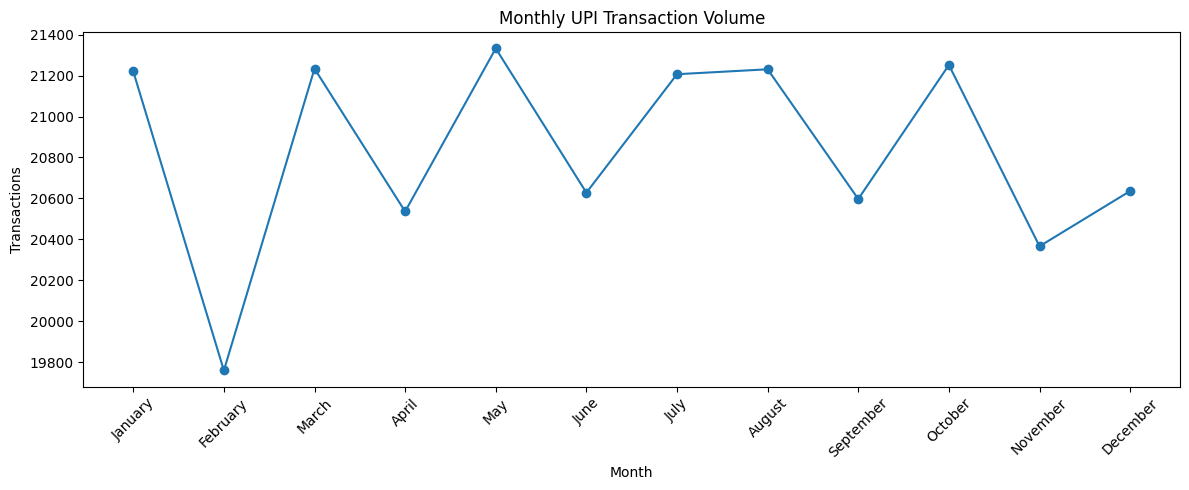

In [35]:
# monthly analysis trend
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["month_name"],
    monthly_analysis["transactions"],
    marker="o"
)

plt.title("Monthly UPI Transaction Volume")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

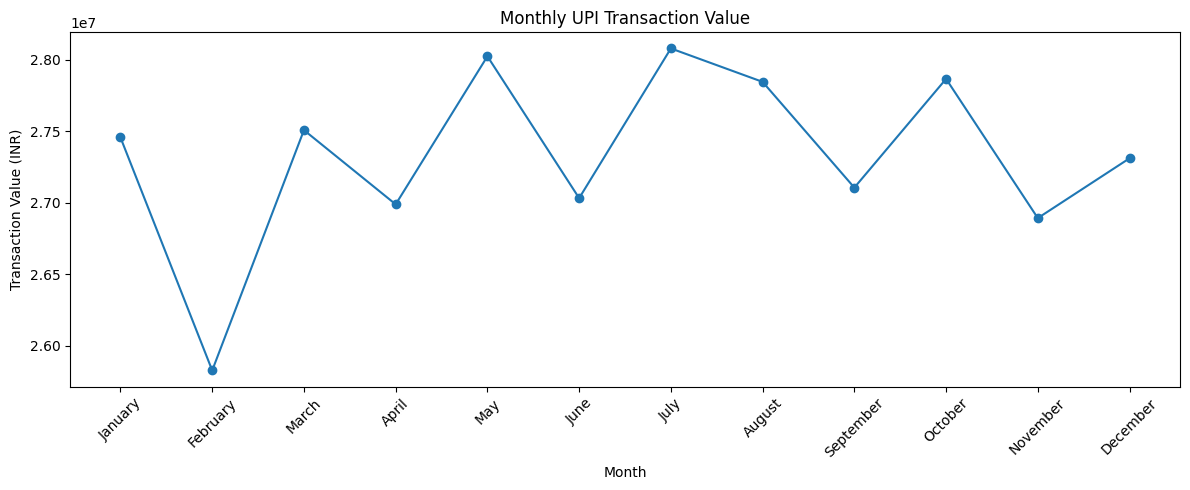

In [36]:
# montly tranction value trend
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_analysis["month_name"],
    monthly_analysis["total_value"],
    marker="o"
)

plt.title("Monthly UPI Transaction Value")
plt.xlabel("Month")
plt.ylabel("Transaction Value (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [38]:
# hr dat analysis
hour_analysis = (
    df.groupby("hour")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          fraud_transactions=("fraud_flag", "sum")
      )
      .reset_index()
)

hour_analysis["fraud_rate_pct"] = (
    hour_analysis["fraud_transactions"]
    / hour_analysis["transactions"] * 100
)

hour_analysis

,hour,transactions,total_value,fraud_transactions,fraud_rate_pct
0,0,3388,4532884,8,0.236128
1,1,2244,2914350,6,0.267380
2,2,1685,2173750,3,0.178042
3,3,1314,1678669,4,0.304414
4,4,1247,1670700,1,0.080192
5,5,1742,2134122,1,0.057405
6,6,3501,4617034,5,0.142816
7,7,5630,7482766,13,0.230906
8,8,8349,10979614,18,0.215595
9,9,10450,13809021,20,0.191388


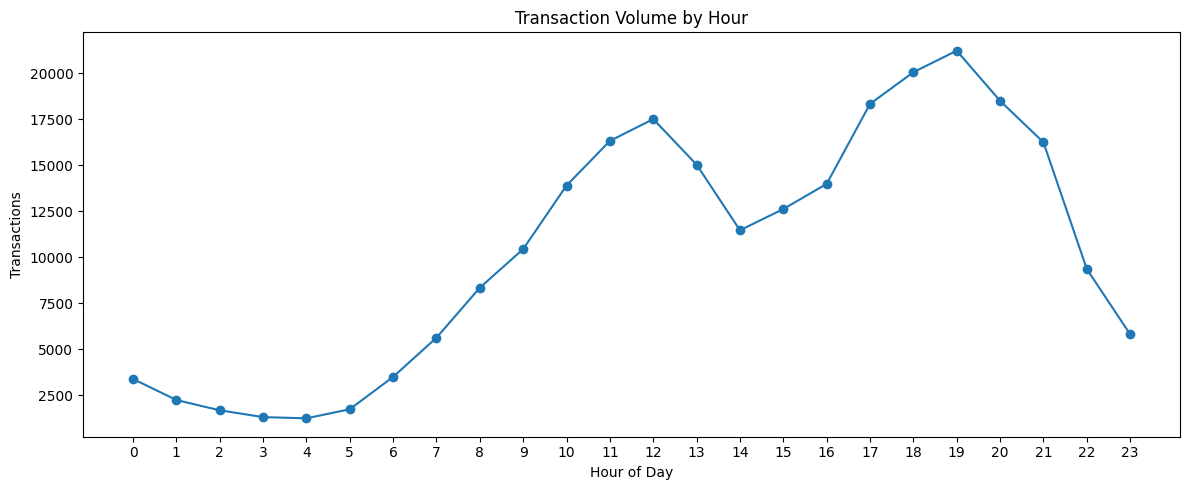

In [39]:
plt.figure(figsize=(12, 5))

plt.plot(
    hour_analysis["hour"],
    hour_analysis["transactions"],
    marker="o"
)

plt.title("Transaction Volume by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.xticks(range(24))

plt.tight_layout()
plt.show()

In [40]:
# success and failure rate by hour
status_analysis = (
    df.groupby("transaction_status")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean")
      )
)

status_analysis

,transactions,total_value,avg_transaction
transaction_status,,,
FAILED,12376,16757197,1354.007515
SUCCESS,237624,311181812,1309.555483


In [41]:
# frud analysis by stust
fraud_status = pd.crosstab(
    df["transaction_status"],
    df["fraud_flag"]
)

fraud_status

fraud_flag,0,1
transaction_status,,
FAILED,12355,21
SUCCESS,237165,459


In [42]:
# frud baseline
fraud_summary = (
    df.groupby("fraud_flag")
      .agg(
          transactions=("transaction_id", "count"),
          total_value=("amount_inr", "sum"),
          avg_transaction=("amount_inr", "mean")
      )
)

fraud_summary

,transactions,total_value,avg_transaction
fraud_flag,,,
0,249520,327219378,1311.395391
1,480,719631,1499.231250


In [43]:
# covert label
fraud_summary.index = [
    "Non-Fraud",
    "Fraud"
]

fraud_summary

,transactions,total_value,avg_transaction
Non-Fraud,249520,327219378,1311.395391
Fraud,480,719631,1499.231250


In [44]:
fraud_by_type = (
    df.groupby("transaction_type")
      .agg(
          transactions=("transaction_id", "count"),
          fraud_transactions=("fraud_flag", "sum")
      )
)

fraud_by_type["fraud_rate_pct"] = (
    fraud_by_type["fraud_transactions"]
    / fraud_by_type["transactions"] * 100
)

fraud_by_type.sort_values(
    "fraud_rate_pct",
    ascending=False
)

,transactions,fraud_transactions,fraud_rate_pct
transaction_type,,,
Recharge,12527,30,0.239483
Bill Payment,37368,77,0.206059
P2M,87660,167,0.190509
P2P,112445,206,0.183201


Advanced Fraud Feature Engineering

df_risk = df.copy()

df_risk = df.copy()

In [45]:
df_risk = df.copy()

In [46]:
df_risk.shape

(250000, 22)

In [47]:
# High-value transaction flag

high_value_threshold = df_risk["amount_inr"].quantile(0.95)

high_value_threshold

np.float64(4687.049999999988)

In [48]:
df_risk["high_value_flag"] = (
    df_risk["amount_inr"] >= high_value_threshold
).astype("int8")

In [49]:
df_risk["high_value_flag"] = (
    df_risk["amount_inr"] >= high_value_threshold
).astype("int8")

In [50]:
df_risk["high_value_flag"] = (
    df_risk["amount_inr"] >= high_value_threshold
).astype("int8")

In [51]:
df_risk["high_value_flag"] = (
    df_risk["amount_inr"] >= high_value_threshold
).astype("int8")

In [52]:
df_risk["high_value_flag"].value_counts()

high_value_flag
0    237500
1     12500
Name: count, dtype: int64

In [53]:
# Night transaction flag
df_risk["night_transaction_flag"] = (
    (df_risk["hour"] >= 22) |
    (df_risk["hour"] <= 5)
).astype("int8")

In [54]:
df_risk["night_transaction_flag"].value_counts()

night_transaction_flag
0    223199
1     26801
Name: count, dtype: int64

In [55]:
df_risk["night_transaction_flag"].value_counts()

night_transaction_flag
0    223199
1     26801
Name: count, dtype: int64

In [56]:
night_analysis = (
    df_risk.groupby("night_transaction_flag")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

night_analysis["fraud_rate_pct"] = (
    night_analysis["fraud_transactions"]
    / night_analysis["transactions"] * 100
)

night_analysis

,transactions,fraud_transactions,fraud_rate_pct
night_transaction_flag,,,
0,223199,425,0.190413
1,26801,55,0.205216


In [57]:
night_analysis = (
    df_risk.groupby("night_transaction_flag")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

night_analysis["fraud_rate_pct"] = (
    night_analysis["fraud_transactions"]
    / night_analysis["transactions"] * 100
)

night_analysis

,transactions,fraud_transactions,fraud_rate_pct
night_transaction_flag,,,
0,223199,425,0.190413
1,26801,55,0.205216


In [58]:
# weekend flag 
df_risk["weekend_flag"] = (
    df_risk["is_weekend"]
    .astype("int8")
)

In [59]:
weekend_analysis = (
    df_risk.groupby("weekend_flag")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

weekend_analysis["fraud_rate_pct"] = (
    weekend_analysis["fraud_transactions"]
    / weekend_analysis["transactions"] * 100
)

weekend_analysis

,transactions,fraud_transactions,fraud_rate_pct
weekend_flag,,,
0,178663,337,0.188623
1,71337,143,0.200457


In [60]:
weekend_analysis = (
    df_risk.groupby("weekend_flag")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

weekend_analysis["fraud_rate_pct"] = (
    weekend_analysis["fraud_transactions"]
    / weekend_analysis["transactions"] * 100
)

weekend_analysis

,transactions,fraud_transactions,fraud_rate_pct
weekend_flag,,,
0,178663,337,0.188623
1,71337,143,0.200457


In [61]:
# Amount percentage analysis
df_risk["amount_percentile"] = (
    df_risk["amount_inr"]
    .rank(pct=True)
)

In [62]:
df_risk[
    ["amount_inr", "amount_percentile"]
].head(10)

,amount_inr,amount_percentile
0,868,0.593298
1,1011,0.633506
2,477,0.410714
3,2784,0.873520
4,990,0.627914
5,91,0.044508
6,314,0.275606
7,264,0.225626
8,887,0.598998
9,3260,0.901210


In [63]:
# Amount based 
bins = [
    0,
    500,
    1000,
    2000,
    5000,
    10000,
    np.inf
]

labels = [
    "≤500",
    "501-1000",
    "1001-2000",
    "2001-5000",
    "5001-10000",
    ">10000"
]

df_risk["amount_band"] = pd.cut(
    df_risk["amount_inr"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [64]:
df_risk["amount_band"].value_counts().sort_index()

amount_band
≤500          106624
501-1000       51037
1001-2000      43184
2001-5000      38199
5001-10000      9151
>10000          1805
Name: count, dtype: int64

In [65]:
# tarnstion velocity 
df_risk["minute"] = df_risk["timestamp"].dt.floor("min")

In [66]:
system_velocity = (
    df_risk.groupby("minute")["transaction_id"]
    .transform("count")
)

df_risk["transactions_per_minute"] = system_velocity

In [67]:
df_risk[
    ["timestamp", "transactions_per_minute"]
].head()

,timestamp,transactions_per_minute
0,2024-10-08 15:17:28,1
1,2024-04-11 06:56:00,1
2,2024-04-02 13:27:18,2
3,2024-01-07 10:09:17,2
4,2024-01-23 19:04:23,2


In [68]:
# velocity system flag 
velocity_threshold = (
    df_risk["transactions_per_minute"]
    .quantile(0.95)
)

velocity_threshold

np.float64(3.0)

In [69]:
df_risk["high_velocity_flag"] = (
    df_risk["transactions_per_minute"]
    >= velocity_threshold
).astype("int8")

In [70]:
velocity_analysis = (
    df_risk.groupby("high_velocity_flag")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

velocity_analysis["fraud_rate_pct"] = (
    velocity_analysis["fraud_transactions"]
    / velocity_analysis["transactions"] * 100
)

velocity_analysis

,transactions,fraud_transactions,fraud_rate_pct
high_velocity_flag,,,
0,212353,412,0.194017
1,37647,68,0.180625


In [71]:
# category level fraud baseline 
category_fraud_rate = (
    df_risk.groupby("merchant_category")["fraud_flag"]
    .mean()
)

In [72]:
category_fraud_rate = (
    category_fraud_rate * 100
)

In [73]:
df_risk["category_fraud_rate_pct"] = (
    df_risk["merchant_category"]
    .map(category_fraud_rate)
)

In [74]:
df_risk["category_fraud_rate_pct"] = (
    df_risk["merchant_category"]
    .map(category_fraud_rate)
)

In [75]:
# sate - lvele basline 
state_fraud_rate = (
    df_risk.groupby("sender_state")["fraud_flag"]
    .mean() * 100
)

df_risk["state_fraud_rate_pct"] = (
    df_risk["sender_state"]
    .map(state_fraud_rate)
)

In [76]:
# BANK level baseline
bank_fraud_rate = (
    df_risk.groupby("sender_bank")["fraud_flag"]
    .mean() * 100
)

df_risk["sender_bank_fraud_rate_pct"] = (
    df_risk["sender_bank"]
    .map(bank_fraud_rate)
)

In [77]:
# composite risk score calculation
df_risk["risk_score"] = (
    df_risk["high_value_flag"] * 2
    + df_risk["night_transaction_flag"]
    + df_risk["weekend_flag"]
    + df_risk["high_velocity_flag"]
)

In [78]:
# risk category 
def classify_risk(score):
    if score >= 4:
        return "High"
    elif score >= 2:
        return "Medium"
    else:
        return "Low"

df_risk["risk_category"] = (
    df_risk["risk_score"]
    .apply(classify_risk)
)

In [79]:
#value count 
df_risk["risk_category"].value_counts()

risk_category
Low       219868
Medium     29177
High         955
Name: count, dtype: int64

In [80]:
risk_validation = (
    df_risk.groupby("risk_category")
    .agg(
        transactions=("transaction_id", "count"),
        fraud_transactions=("fraud_flag", "sum")
    )
)

risk_validation["fraud_rate_pct"] = (
    risk_validation["fraud_transactions"]
    / risk_validation["transactions"] * 100
)

risk_validation

,transactions,fraud_transactions,fraud_rate_pct
risk_category,,,
High,955,4,0.418848
Low,219868,402,0.182837
Medium,29177,74,0.253624


In [81]:
risk_columns = [
    "transaction_id",
    "timestamp",
    "amount_inr",
    "transaction_type",
    "merchant_category",
    "transaction_status",
    "sender_state",
    "sender_bank",
    "receiver_bank",
    "device_type",
    "network_type",
    "fraud_flag",
    "high_value_flag",
    "night_transaction_flag",
    "weekend_flag",
    "amount_percentile",
    "amount_band",
    "transactions_per_minute",
    "high_velocity_flag",
    "category_fraud_rate_pct",
    "state_fraud_rate_pct",
    "sender_bank_fraud_rate_pct",
    "risk_score",
    "risk_category"
]

df_risk[risk_columns].head()

,transaction_id,timestamp,amount_inr,transaction_type,merchant_category,transaction_status,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,high_value_flag,night_transaction_flag,weekend_flag,amount_percentile,amount_band,transactions_per_minute,high_velocity_flag,category_fraud_rate_pct,state_fraud_rate_pct,sender_bank_fraud_rate_pct,risk_score,risk_category
0,TXN0000000001,2024-10-08 15:17:28,868,P2P,Entertainment,SUCCESS,Delhi,Axis,SBI,Android,4G,0,0,0,0,0.593298,501-1000,1,0,0.198975,0.201045,0.195671,0,Low
1,TXN0000000002,2024-04-11 06:56:00,1011,P2M,Grocery,SUCCESS,Uttar Pradesh,ICICI,Axis,iOS,4G,0,0,0,0,0.633506,1001-2000,1,0,0.188128,0.172614,0.221707,0,Low
2,TXN0000000003,2024-04-02 13:27:18,477,P2P,Grocery,SUCCESS,Karnataka,Yes Bank,PNB,Android,4G,0,0,0,0,0.410714,≤500,2,0,0.188128,0.231886,0.160901,0,Low
3,TXN0000000004,2024-01-07 10:09:17,2784,P2P,Fuel,SUCCESS,Delhi,ICICI,PNB,Android,5G,0,0,0,1,0.873520,2001-5000,2,0,0.191517,0.201045,0.221707,1,Low
4,TXN0000000005,2024-01-23 19:04:23,990,P2P,Shopping,SUCCESS,Delhi,Axis,Yes Bank,iOS,WiFi,0,0,0,0,0.627914,501-1000,2,0,0.207552,0.201045,0.195671,0,Low


In [82]:
df_risk.shape

(250000, 35)